# G2ELin — a tour of every `g2elin_core` module

This notebook exercises every module in `g2elin_core` directly (no web UI,
no API layer) in the order data actually flows through the tool:

`network` (schema/presets) → `pu_base` → `powerflow` → `network.topology`
→ `operating_point` → `components` → `interconnect` → `pipeline`
→ `modal` (`analysis` + `toolbox`) → `timedomain` (EMT) → `timeseries`

Each section calls the module's real public functions on a real preset
network (mostly `wscc9_3sm`, the WSCC 9-bus 3-synchronous-machine case) and
plots or prints the result — nothing here is mocked. It's meant as a
runnable reference for exploring the library interactively, alongside the
Sphinx docs (`docs/sphinx`, built via `python tools/build_docs.py`) and the
web UI (`g2elin_api` + `web/index.html`), which wrap the same functions
behind HTTP/JS.

**Setup**: from `python/`, `pip install -e ".[notebook]"` (adds
`jupyterlab`/`ipykernel`/`matplotlib` on top of the core dependencies),
then run this notebook with that environment's kernel.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

### Run-time toggles

Section 11 (`timedomain` -- EMT) is one of the slowest cells in this
notebook: a full *nonlinear* coupled-Newton time integration, not just
linear algebra, so a single EMT trajectory takes tens of seconds (see
that section's own markdown for exact figures). Defaults to **off** so
"Restart Kernel and Run All" finishes quickly; flip the flag to `True`
and re-run to actually exercise that section.

In [2]:
RUN_EMT_SECTION = False  # Section 11: nonlinear EMT time-domain simulation


## 1. `network` — schema and presets

`g2elin_core.network.schema` is the typed model (`Network`, `Bus`, `Line`,
`Transformer`, `Load`, `DerUnit`) that replaces the MATLAB tool's
`Y_network`/`Y_line`/`Y_TR`/`Y_DER` numeric-column convention. `presets.py`
ships five networks; we'll use `wscc9_3sm()` as the running example.

In [3]:
from g2elin_core.network.presets import (
    wscc9_1sm_1gfm_1gfl,
    cigre_islanded_1sm_2gfm_1gfl,
    sm_smib,
    gfm_smib,
    gfl_smib,
)

net = wscc9_1sm_1gfm_1gfl()
print(net.name, "--", net.f_hz, "Hz,", net.sn_mva, "MVA base")
print(f"{len(net.buses)} buses, {len(net.lines)} lines, {len(net.transformers)} transformers, "
      f"{len(net.loads)} loads, {len(net.der_units)} DER units")
for der in net.der_units:
    print(f"  DER {der.id}: {der.unit_type.value:12s} bus={der.bus:2d} bus_type={der.bus_type.value:6s} "
          f"P={der.p_set_mw:6.1f} MW  V_set={der.v_set_pu} pu")

WSCC_1SM_1GFM_1GFL -- 60.0 Hz, 100.0 MVA base
9 buses, 6 lines, 3 transformers, 3 loads, 3 DER units
  DER 1: sm           bus= 7 bus_type=slack  P=  80.0 MW  V_set=1.025 pu
  DER 2: gfm          bus= 8 bus_type=pv     P= 105.0 MW  V_set=1.0 pu
  DER 3: gfl          bus= 9 bus_type=pq     P= 105.0 MW  V_set=1.0 pu


In [4]:
# All five presets, at a glance -- the other four exist for comparison.
for factory in (wscc9_1sm_1gfm_1gfl, cigre_islanded_1sm_2gfm_1gfl, sm_smib, gfm_smib, gfl_smib):
    n = factory()
    types = sorted({d.unit_type.value for d in n.der_units})
    print(f"{factory.__name__:32s} {n.name:45s} buses={len(n.buses):2d}  der_types={types}")

wscc9_1sm_1gfm_1gfl              WSCC_1SM_1GFM_1GFL                            buses= 9  der_types=['gfl', 'gfm', 'sm']
cigre_islanded_1sm_2gfm_1gfl     CIGRE_Islanded_1SM_2GFM_1GFL                  buses=18  der_types=['gfl', 'gfm', 'sm']
sm_smib                          SMIB_sm                                       buses= 4  der_types=['infinite_bus', 'sm']
gfm_smib                         SMIB_gfm                                      buses= 4  der_types=['gfm', 'infinite_bus']
gfl_smib                         SMIB_gfl                                      buses= 4  der_types=['gfl', 'infinite_bus']


## 2. `pu_base` — per-unit base values

Ported from `Functions/PU_calc.m`. Note the amplitude-invariant convention
(`Ub = sqrt(2/3)*Ul`) rather than RMS -- see the module docstring for why
that still reduces to the familiar `Zb = Un_kV^2 / Sn_MVA` for the R/X/B
conversions used elsewhere.

In [5]:
import math
from g2elin_core.pu_base import pu_base

base = pu_base(wb=2 * math.pi * net.f_hz, un_kv=net.buses[0].vn_kv, sn_mva=net.sn_mva)
base

PuBase(ub=187794.21361337698, ib=354.9985134468375, zb=528.9999999999999, lb=1.4032160815935437, cb=5.014333430746547e-06, ub_dc=375588.42722675396, ib_dc=266.2488850851281, zb_dc=1410.6666666666663, cb_dc=1.880375036529955e-06)

## 3. `powerflow` — static load flow (pandapower adapter)

`build_pandapower_net()` translates a `Network` into a pandapower net
(slack DER -> `ext_grid`, PV DER -> `gen`, PQ DER -> `sgen`), and
`run_power_flow()` solves it. `PowerFlowResult` re-indexes every result
table back to this project's own bus ids.

In [6]:
from g2elin_core.powerflow import run_power_flow

pf = run_power_flow(net)
print("converged:", pf.converged, " total losses:", round(pf.total_losses_mw(), 4), "MW")
pf.bus_table()

converged: True  total losses: 3.4332 MW


,bus,vm_pu,va_degree,p_net_gen_mw,q_net_gen_mvar
0,1,1.0125,-3.4501,-0.0000,-0.0000
1,2,1.0065,-1.4543,-0.0000,-0.0000
2,3,1.0251,-0.5580,-0.0000,-0.0000
3,4,0.9819,-6.6778,-125.0000,-50.0000
4,5,1.0013,-3.3993,-100.0000,-35.0000
5,6,1.0015,-5.4255,-90.0000,-30.0000
6,7,1.0250,0.0000,108.4332,25.4322
7,8,1.0000,2.2839,105.0000,-7.0519
8,9,1.0233,2.8045,105.0000,-0.0000


In [7]:
# The other result tables PowerFlowResult exposes, one call each.
display(pf.line_table().head())
display(pf.trafo_table())
display(pf.gen_table())

,name,from_bus,to_bus,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,,1,4,69.4090,21.1695,-68.8502,-33.9261,0.5588,-12.7566,0.1799,0.1962,0.1962,1.0125,-3.4501,0.9819,-6.6778,0.0196
1,,1,6,39.0241,-2.5380,-38.7665,-12.0913,0.2576,-14.6294,0.0969,0.1018,0.1018,1.0125,-3.4501,1.0015,-5.4255,0.0102
2,,2,4,57.1968,-8.9106,-56.1498,-16.0739,1.0470,-24.9845,0.1444,0.1493,0.1493,1.0065,-1.4543,0.9819,-6.6778,0.0149
3,,2,5,47.8032,-5.0630,-47.6110,-8.3261,0.1922,-13.3891,0.1199,0.1212,0.1212,1.0065,-1.4543,1.0013,-3.3993,0.0121
4,,3,5,52.7459,8.2383,-52.3890,-26.6739,0.3569,-18.4356,0.1307,0.1474,0.1474,1.0251,-0.5580,1.0013,-3.3993,0.0148


,name,hv_bus,lv_bus,p_hv_mw,q_hv_mvar,p_lv_mw,q_lv_mvar,pl_mw,ql_mvar,i_hv_ka,i_lv_ka,vm_hv_pu,va_hv_degree,vm_lv_pu,va_lv_degree,loading_percent
0,gen1_xfmr,1,7,-108.4332,-18.6315,108.4332,2.5432e+01,1.4211e-14,6.8007,0.2728,3.4852,1.0125,-3.4501,1.0250,0.0000,108.6592
1,gen2_xfmr,2,8,-105.0000,13.9736,105.0000,-7.0519e+00,0.0000e+00,6.9217,0.2642,3.3755,1.0065,-1.4543,1.0000,2.2839,105.2365
2,gen3_xfmr,3,9,-105.0000,6.1693,105.0000,7.7246e-10,-1.4211e-14,6.1693,0.2576,3.2911,1.0251,-0.5580,1.0233,2.8045,102.6054


,name,bus,p_mw,q_mvar,va_degree,vm_pu
0,der2,8,105.0,-7.0519,2.2839,1.0


## 4. `network.topology` — 2D layout for diagrams

`compute_topology_layout()` runs a Kamada-Kawai spring layout over the bus
graph (lines/transformers as edges) -- this is exactly what feeds the web
UI's Network/Power Flow/Time Series diagrams (`renderNetworkDiagram()` in
`web/index.html`). Each node/edge also carries its own electrical/control
parameters, not just position -- the same data the UI's click-to-inspect
panel shows.

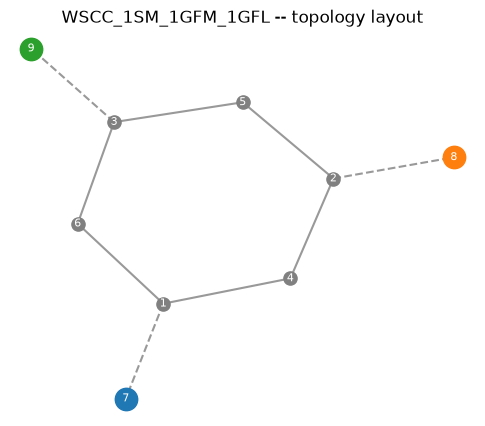

Bus 7 control_params (sm_params(), truncated):


{'wb': 376.99111843077515,
 'Rt': 0.0,
 'Lt': 0.0576,
 'RL_pu': 1000.0,
 'Ra': 0.003,
 'Ll': 0.15,
 'Lad': 1.66,
 'Laq': 1.61}

In [8]:
from g2elin_core.network.topology import compute_topology_layout

topo = compute_topology_layout(net)

fig, ax = plt.subplots(figsize=(6, 5))
pos = {n.id: (n.x, n.y) for n in topo.nodes}
for e in topo.edges:
    x1, y1 = pos[e.from_bus]
    x2, y2 = pos[e.to_bus]
    style = "--" if e.kind == "transformer" else "-"
    ax.plot([x1, x2], [y1, y2], style, color="0.6", zorder=1)
colors = {"sm": "tab:blue", "gfm": "tab:orange", "gfl": "tab:green", "infinite_bus": "tab:red", None: "0.5"}
for n in topo.nodes:
    ax.scatter(*pos[n.id], s=260 if n.unit_type else 90, color=colors[n.unit_type], zorder=2)
    ax.annotate(f"{n.id}", pos[n.id], ha="center", va="center", fontsize=8, color="white", zorder=3)
ax.set_title(f"{net.name} -- topology layout")
ax.set_axis_off()
plt.show()

sm_bus = next(n for n in topo.nodes if n.der_info and n.der_info["unit_type"] == "sm")
print("Bus", sm_bus.id, "control_params (sm_params(), truncated):")
{k: sm_bus.der_info["control_params"][k] for k in list(sm_bus.der_info["control_params"])[:8]}

## 5. `operating_point` — bridging a solved power flow to per-component operating points

`compute_operating_point()` ports `script_generic.m`'s "SM
Initializations"/node/line/load operating-point loops -- everything each
component's linearizer needs (terminal voltage/angle, P/Q, the global
reference angle) is computed once here from the solved `PowerFlowResult`.
`sm_params()`/`gfm_params()`/`gfl_params()` (also in this module) are the
*default electrical/control tuning* each unit type uses, transcribed from
`script_generic.m`'s "Defining Default Tuning" section.

In [9]:
from g2elin_core.operating_point import compute_operating_point, sm_params

op = compute_operating_point(net, pf)
print("global reference angle theta_g_rad:", op.theta_g_rad)
print("SM operating points for DER ids:", list(op.sm_ops.keys()))

# SmOperatingPoint's constructor takes v_terminal_pu/angle_terminal_rad/etc,
# but stores everything already resolved into the machine's own dq-frame
# operating point (theta0, Et0 terminal-voltage magnitude, Pm0 mechanical
# power, flux linkages...) rather than echoing the raw inputs back.
sm_op = next(iter(op.sm_ops.values()))
print("\nFirst SM operating point (dq-frame, already resolved):")
print(f"  theta0 (rotor angle) = {sm_op.theta0:.4f} rad")
print(f"  Et0 (terminal voltage magnitude) = {sm_op.Et0:.4f} pu")
print(f"  Pm0 (mechanical power) = {sm_op.Pm0:.4f} pu")
print(f"  is_slack = {sm_op.is_slack}")

global reference angle theta_g_rad: -0.6663671166702527
SM operating points for DER ids: [1]

First SM operating point (dq-frame, already resolved):
  theta0 (rotor angle) = -0.6664 rad
  Et0 (terminal voltage magnitude) = 1.0250 pu
  Pm0 (mechanical power) = 1.0853 pu
  is_slack = True


## 6. `components` — one symbolic DAE per unit type, linearized numerically

Every `components/*.py` module builds a full nonlinear DAE symbolically
(`sm_dae()`, `gfm_dae()`, `gfl_dae()`, `ib_dae()`, `line_dae()`,
`load_dae()`, `node_dae()` -- all return a `ComponentDAE`), then
`linearize_*(operating_point)` substitutes numbers and eliminates the
algebraic variables to get a `LinearComponent` (`A`/`B`/`C`/`D` plus
input/output/state names). This is the same symbolic-then-numeric split
`components/base.py`'s module docstring describes.

In [10]:
from g2elin_core.components.sm import sm_dae, linearize_sm

dae = sm_dae(is_slack=sm_op.is_slack)
print(f"SM symbolic DAE: {len(dae.state_syms)} states, {len(dae.alg_syms)} algebraic vars, "
      f"{len(dae.param_syms())} free parameters")
print("states:", dae.state_names)
print("own inputs (us):", dae.input_names, " own outputs (s):", dae.output_names)

lin = linearize_sm(sm_op)
print(f"\nlinearized: A is {lin.A.shape}, B is {lin.B.shape}, C is {lin.C.shape}, D is {lin.D.shape}")
print("eigenvalues of this ONE machine's own A (before interconnection):")
print(np.linalg.eigvals(lin.A))

SM symbolic DAE: 19 states, 15 algebraic vars, 34 free parameters
states: ['i_gd', 'i_gq', 'psi_d', 'psi_q', 'psi_fd', 'psi_1d', 'psi_1q', 'psi_2q', 'dw_r', 'theta', 'P_m', 'dw_1', 'v_1', 'v_2', 'v_pss', 'e_1', 'e_2', 'e_fd', 'e_3']
own inputs (us): ['V_ref', 'P_ref', 'w_ref']  own outputs (s): ['p_e', 'q_e', 'w_r', 'theta', 'dw_r_dot', 'V_t']

linearized: A is (19, 19), B is (19, 5), C is (10, 19), D is (10, 5)
eigenvalues of this ONE machine's own A (before interconnection):
[       0.       +0.j     -8052958.3052   +0.j
 -8184111.6663   +0.j        -5503.7048+3129.008j
    -5503.7048-3129.008j        -3.8463 +377.0406j
       -3.8463 -377.0406j      -50.482    +0.j
      -50.       +0.j          -40.8843   +0.j
      -33.1148   +0.0677j      -33.1148   -0.0677j
       -2.38     +9.7788j       -2.38     -9.7788j
       -2.0877   +2.7558j       -2.0877   -2.7558j
       -2.5539   +0.j           -0.4733   +0.j
       -0.1754   +0.j    ]


In [11]:
# The same DAE also lambdifies to numeric nonlinear callables f/g/h -- what
# EMT time-domain simulation (section 11) actually integrates, not a
# separate re-derivation.
from g2elin_core.components.sm import sm_nonlinear_point

x0, z0, u0, p0 = sm_nonlinear_point(sm_op)
funcs = dae.nonlinear_funcs()
residual_at_operating_point = funcs.g(x0, z0, u0, p0)
print("max |g(x0, z0, u0, p0)| at the operating point (should be ~0):",
      float(np.max(np.abs(residual_at_operating_point))))

max |g(x0, z0, u0, p0)| at the operating point (should be ~0): 6.783462680459706e-14


## 7. `interconnect` — wiring components into one closed-loop system

`network_assembly.build_blocks_and_wiring()` decides which `Block`s exist
(one per DER/node/line/load, named `SM_1`/`GFM_1`/`GFL_1`/`IB_1` by
per-type counter) and which `Wiring` rules connect their ports;
`assemble.compute_topology()` turns that into `F`/`G` selector matrices,
and `assemble.assemble()` does the closed-loop elimination
(`A_tot = A_ol + B_ol @ G @ E_ol @ C_ol`, etc.) to produce one
`AssembledSystem`. `assemble_network()` is the one-call version we'll use
directly (the same one `pipeline.linearize_network()` calls internally).

In [12]:
from g2elin_core.components.gfl import linearize_gfl
from g2elin_core.components.gfm import linearize_gfm
from g2elin_core.components.ib import linearize_ib
from g2elin_core.components.line import linearize_line
from g2elin_core.components.load import linearize_load
from g2elin_core.components.node import linearize_node
from g2elin_core.interconnect import assemble_network

wb_val = 2 * math.pi * net.f_hz
der_components = {i: linearize_sm(o) for i, o in op.sm_ops.items()}
der_components.update({i: linearize_gfm(o) for i, o in op.gfm_ops.items()})
der_components.update({i: linearize_gfl(o) for i, o in op.gfl_ops.items()})
der_components.update({i: linearize_ib(**kw) for i, kw in op.ib_ops.items()})

b_pu_quirk = net.lines[0].b_pu
node_components = {
    bus_id: linearize_node(wb_val=wb_val, b_pu=b_pu_quirk, wg0=1.0, vgd_g0=vgd, vgq_g0=vgq)
    for bus_id, (vgd, vgq) in op.node_vg.items()
}
line_components = [
    linearize_line(wb_val=wb_val, r_pu=ln.r_pu, x_pu=ln.x_pu, wg0=1.0, ild_g0=i0[0], ilq_g0=i0[1])
    for ln, i0 in zip(net.lines, op.line_i0)
]
load_components = []
for idx, load in enumerate(net.loads):
    r_pu, x_pu = op.load_rx[idx]
    vgd, vgq = op.node_vg[load.bus]
    load_components.append(linearize_load(wb_val=wb_val, r_pu=r_pu, x_pu=x_pu, wg0=1.0, vgd_g0=vgd, vgq_g0=vgq))

system = assemble_network(
    net, der_components=der_components, node_components=node_components,
    line_components=line_components, load_components=load_components,
)
print(f"Assembled closed-loop system: {system.A.shape[0]} states, "
      f"{len(system.input_names)} inputs, {len(system.output_names)} outputs")
print("first 8 state names:", system.state_names[:8])

Assembled closed-loop system: 78 states, 11 inputs, 14 outputs
first 8 state names: ['i_gd_{SM_1}', 'i_gq_{SM_1}', 'psi_d_{SM_1}', 'psi_q_{SM_1}', 'psi_fd_{SM_1}', 'psi_1d_{SM_1}', 'psi_1q_{SM_1}', 'psi_2q_{SM_1}']


## 8. `pipeline` — the one-call version of sections 5-7

`linearize_network(network, result)` does exactly what the last three
sections did by hand: `compute_operating_point()` -> one `linearize_*()`
per component -> `assemble_network()`. This is what `g2elin_api` calls for
the Power Flow -> Modal Analysis path; the rest of this notebook uses it
instead of repeating section 7's wiring.

In [13]:
from g2elin_core.pipeline import linearize_network

system = linearize_network(net, pf)
assert system.A.shape[0] == len(system.state_names)
print("same result as the manual assembly:", system.A.shape)

same result as the manual assembly: (78, 78)


## 9. `modal.analysis` — eigenvalues and participation factors

`analyze(A, state_names)` eigen-decomposes the closed-loop `A` matrix
(`scipy.linalg.eig`, left and right eigenvectors from one call so they're
consistently paired) and computes the participation-factor matrix.
`summary_table()` mirrors `modal_analysis.m`'s printed table -- eigenvalue,
frequency/damping, and the top-3 participating states per mode.

In [14]:
from g2elin_core.modal import analyze

modal = analyze(system.A, system.state_names)
summary = modal.summary_table()
print("stable:", bool(np.all(modal.eigenvalues.real < 0)), " max Re(lambda):", modal.eigenvalues.real.max())
summary.sort_values("undamped_hz").head(10)

stable: True  max Re(lambda): -1.9020643065397202e-10


,mode,real,imag,undamped_hz,damped_hz,damping_pct,state1,part1_pct,state2,part2_pct,state3,part3_pct
77,77,-1.9021e-10,0.0000,3.0272e-11,0.0000,100.0000,theta_{SM_1},54.1831,theta_{GFM_1},45.8134,theta_pll_{GFL_1},0.0035
76,76,-1.8431e-01,0.0000,2.9334e-02,0.0000,100.0000,v_pss_{SM_1},98.2015,v_2_{SM_1},0.5752,dw_1_{SM_1},0.4691
75,75,-4.9767e-01,0.0000,7.9207e-02,0.0000,100.0000,v_1_{SM_1},96.8458,v_2_{SM_1},1.3767,v_pss_{SM_1},0.7216
74,74,-1.6248e+00,0.0000,2.5860e-01,0.0000,100.0000,psi_1q_{SM_1},77.7664,theta_{GFM_1},9.3520,psi_2q_{SM_1},5.2167
69,69,-4.8127e+00,0.0000,7.6597e-01,0.0000,100.0000,theta_{GFM_1},43.3558,P_m_{SM_1},31.9141,psi_1q_{SM_1},12.2403
70,70,-2.8507e+00,5.3512,9.6498e-01,0.8517,47.0173,psi_fd_{SM_1},35.0132,e_fd_{SM_1},29.6162,e_3_{SM_1},20.1033
71,71,-2.8507e+00,-5.3512,9.6498e-01,0.8517,47.0173,psi_fd_{SM_1},35.0132,e_fd_{SM_1},29.6162,e_3_{SM_1},20.1033
72,72,-2.4084e+00,-12.8458,2.0801e+00,2.0445,18.4271,dw_r_{SM_1},42.2879,P_m_{SM_1},24.6245,theta_{SM_1},17.1646
73,73,-2.4084e+00,12.8458,2.0801e+00,2.0445,18.4271,dw_r_{SM_1},42.2879,P_m_{SM_1},24.6245,theta_{SM_1},17.1646
58,58,-2.8443e+01,2.7745,4.5483e+00,0.4416,99.5276,p_m_{GFM_1},37.4365,psi_2q_{SM_1},21.2730,psi_1d_{SM_1},9.6600


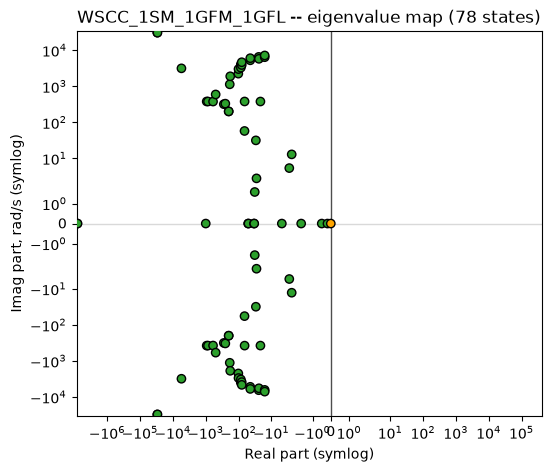

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = np.where(modal.eigenvalues.real > 1e-6, "red",
          np.where(modal.eigenvalues.real > -1e-3, "orange", "tab:green"))
ax.scatter(modal.eigenvalues.real, modal.eigenvalues.imag, c=colors, edgecolor="k", zorder=3)
ax.axvline(0, color="0.3", lw=1)
ax.axhline(0, color="0.85", lw=1)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.set_xlabel("Real part (symlog)")
ax.set_ylabel("Imag part, rad/s (symlog)")
ax.set_title(f"{net.name} -- eigenvalue map ({len(modal.eigenvalues)} states)")
plt.show()

## 9b. Root locus: retuning a GFM's inner current-loop time constant

`script_generic.m`'s "Inner Current Loop" tuning block (`Inner_current_loop.tr`,
a closed-loop rise-time target) pole-places `KpCL`/`KiCL` via
`wn_cl = 3/(zita*tr_cl)`, `KpCL = (2*zita*wn_cl*tau_i - 1)/KiCL_gain`,
`KiCL = wn_cl^2*tau_i/KiCL_gain` -- transcribed unchanged into
`operating_point.gfm_params(..., tr_cl=...)`. Every preset always used the
same fixed `tr_cl = 0.1 ms`; `gfm_params()` now takes it as an optional
keyword (default unchanged) specifically so it can be swept like this.

This uses `cigre_islanded_1sm_2gfm_1gfl()` -- a real meshed network (1 SM
slack + **2** GFM units + 1 GFL), not the trivial 2-DER SMIB case, so a
retuned current loop can actually interact with other units through the
network rather than only an infinite bus. With two GFMs present, only the
*first* one (`GFM_1`, lower DER id, by this project's declaration-order
naming convention -- see `interconnect.md`) has its current loop swept;
the SM slack, `GFM_2`, and the GFL stay fixed at their normal operating
point and are re-linearized once, outside the sweep, since only `GFM_1`'s
own `KpCL`/`KiCL` change across it.

In [16]:
from g2elin_core.network.presets import wscc9_1sm_1gfm_1gfl
from g2elin_core.operating_point import gfm_params
from g2elin_core.components.gfl import linearize_gfl
from g2elin_core.components.gfm import linearize_gfm
from g2elin_core.components.line import linearize_line
from g2elin_core.components.load import linearize_load
from g2elin_core.components.node import linearize_node
from g2elin_core.interconnect import assemble_network

gfm_net = wscc9_1sm_1gfm_1gfl()
gfm_pf = run_power_flow(gfm_net)
assert gfm_pf.converged
gfm_full_op = compute_operating_point(gfm_net, gfm_pf)

# Two GFMs -- sweep the lower-id one only ("GFM_1" by the project's own
# per-type block-naming convention, since network.der_units is always
# declared in ascending id order -- see interconnect.md).
der_gfm_id = min(gfm_full_op.gfm_ops)
der_gfm = next(d for d in gfm_net.der_units if d.id == der_gfm_id)
gfm_op = gfm_full_op.gfm_ops[der_gfm_id]
first_tr = gfm_net.transformers[0]
un_kv = gfm_net.bus(der_gfm.bus).vn_kv

# Reproduce build_blocks_and_wiring()'s per-type block-name counter locally
# (declaration order -> "SM_1"/"GFM_1"/"GFM_2"/"GFL_1") just to know which
# state-name suffix is GFM_1's own, so its current-loop pole can be told
# apart from GFM_2's identically-named M_CLd/M_CLq states below.
_type_label = {"sm": "SM", "gfm": "GFM", "gfl": "GFL", "infinite_bus": "IB"}
_type_counters = {}
block_name_by_der_id = {}
for der in gfm_net.der_units:
    label = _type_label[der.unit_type.value]
    _type_counters[label] = _type_counters.get(label, 0) + 1
    block_name_by_der_id[der.id] = f"{label}_{_type_counters[label]}"
swept_block_name = block_name_by_der_id[der_gfm_id]
print("sweeping the current loop of block:", swept_block_name)

# Everything except the swept GFM's own current-loop gains is
# tr_cl-independent -- build it once, outside the sweep.
gfm_wb_val = 2 * math.pi * gfm_net.f_hz
fixed_der_components = {i: linearize_sm(o) for i, o in gfm_full_op.sm_ops.items()}
fixed_der_components.update(
    {i: linearize_gfm(o) for i, o in gfm_full_op.gfm_ops.items() if i != der_gfm_id}
)
fixed_der_components.update({i: linearize_gfl(o) for i, o in gfm_full_op.gfl_ops.items()})

gfm_b_pu_quirk = gfm_net.lines[0].b_pu
gfm_node_components = {
    bus_id: linearize_node(wb_val=gfm_wb_val, b_pu=gfm_b_pu_quirk, wg0=1.0, vgd_g0=vgd, vgq_g0=vgq)
    for bus_id, (vgd, vgq) in gfm_full_op.node_vg.items()
}
gfm_line_components = [
    linearize_line(wb_val=gfm_wb_val, r_pu=ln.r_pu, x_pu=ln.x_pu, wg0=1.0, ild_g0=i0[0], ilq_g0=i0[1])
    for ln, i0 in zip(gfm_net.lines, gfm_full_op.line_i0)
]
gfm_load_components = []
for idx, load in enumerate(gfm_net.loads):
    r_pu, x_pu = gfm_full_op.load_rx[idx]
    vgd, vgq = gfm_full_op.node_vg[load.bus]
    gfm_load_components.append(
        linearize_load(wb_val=gfm_wb_val, r_pu=r_pu, x_pu=x_pu, wg0=1.0, vgd_g0=vgd, vgq_g0=vgq)
    )

tr_cl_values = np.array([0.03e-3, 0.05e-3, 0.1e-3, 0.2e-3, 0.4e-3, 0.8e-3, 1.6e-3, 3.2e-3])
sweep = []
for tr_cl in tr_cl_values:
    p = gfm_params(sn_mva=gfm_net.sn_mva, f_hz=gfm_net.f_hz, un_kv=un_kv,
                    rt_pu=first_tr.r_pu, lt_pu=first_tr.x_pu, tr_cl=tr_cl)
    gfm_op.p["KpCL"], gfm_op.p["KiCL"] = p["KpCL"], p["KiCL"]  # only these two change with tr_cl

    gfm_der_components = {**fixed_der_components, der_gfm_id: linearize_gfm(gfm_op)}
    sys_i = assemble_network(
        gfm_net, der_components=gfm_der_components, node_components=gfm_node_components,
        line_components=gfm_line_components, load_components=gfm_load_components,
    )
    modal_i = analyze(sys_i.A, sys_i.state_names)

    # Track "GFM_1's own current-loop pole": the mode where GFM_1's own
    # M_CLd/M_CLq (current-loop PI integrator states) participate the most
    # -- suffix-matched to its own block name so GFM_2's identically-named
    # states don't get mixed in.
    suffix = f"{{{swept_block_name}}}"
    cl_idx = [i for i, n in enumerate(modal_i.state_names) if "M_CL" in n and n.endswith(suffix)]
    cl_mode = int(np.argmax(modal_i.participation[cl_idx, :].sum(axis=0)))
    cl_eig = modal_i.eigenvalues[cl_mode]
    sweep.append(dict(tr_cl=tr_cl, KpCL=p["KpCL"], KiCL=p["KiCL"],
                       eigenvalues=modal_i.eigenvalues, cl_eig=cl_eig, cl_stable=bool(cl_eig.real < 0)))

print(f"{'tr_cl (ms)':>10}  {'KpCL':>8}  {'KiCL':>9}  {'current-loop pole (rad/s)':>28}  cl_pole_stable")
for s in sweep:
    lam = s["cl_eig"]
    print(f"{s['tr_cl']*1e3:10.3f}  {s['KpCL']:8.3f}  {s['KiCL']:9.1f}  "
          f"{lam.real:+10.3e} {lam.imag:+10.3e}j  {s['cl_stable']}")

sweeping the current loop of block: GFM_1
tr_cl (ms)      KpCL       KiCL     current-loop pole (rad/s)  cl_pole_stable
     0.030    53.042  5306767.4  -9.961e+04 +1.002e+05j  True
     0.050    31.821  1910436.3  -5.961e+04 +6.023e+04j  True
     0.100    15.905   477609.1  -2.962e+04 +3.043e+04j  True
     0.200     7.948   119402.3  -1.462e+04 +1.581e+04j  True
     0.400     3.969    29850.6  -7.063e+03 +8.985e+03j  True
     0.800     1.979     7462.6  -2.954e+03 +6.227e+03j  True
     1.600     0.985     1865.7  +4.330e+01 +3.115e+02j  False
     3.200     0.487      466.4  +7.037e+01 -2.229e+02j  False


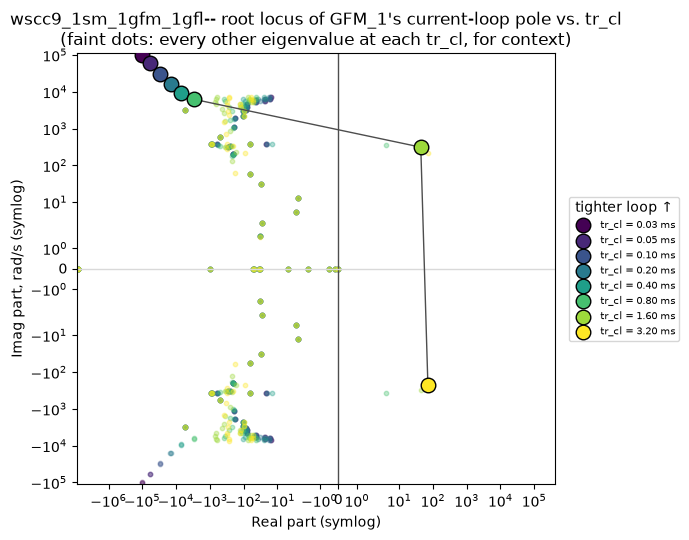

In [17]:
fig, ax = plt.subplots(figsize=(7, 5.5))
log_tr = np.log10(tr_cl_values)
norm = (log_tr - log_tr.min()) / (log_tr.max() - log_tr.min())
colors = plt.cm.viridis(norm)

for s, c in zip(sweep, colors):
    ax.scatter(s["eigenvalues"].real, s["eigenvalues"].imag, s=10, color=c, alpha=0.35, zorder=2)

cl_re = [s["cl_eig"].real for s in sweep]
cl_im = [s["cl_eig"].imag for s in sweep]
ax.plot(cl_re, cl_im, "-", color="0.3", lw=1, zorder=3)
for s, c in zip(sweep, colors):
    ax.scatter([s["cl_eig"].real], [s["cl_eig"].imag], s=110, color=c, edgecolor="k", zorder=4,
               label=f"tr_cl = {s['tr_cl'] * 1e3:.2f} ms")

ax.axvline(0, color="0.3", lw=1)
ax.axhline(0, color="0.85", lw=1)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.set_xlabel("Real part (symlog)")
ax.set_ylabel("Imag part, rad/s (symlog)")
ax.set_title(f"wscc9_1sm_1gfm_1gfl-- root locus of {swept_block_name}'s current-loop pole vs. tr_cl\n"
             "(faint dots: every other eigenvalue at each tr_cl, for context)")
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5), title="tighter loop ↑")
plt.tight_layout()
plt.show()

Tightening the loop (smaller `tr_cl`, higher bandwidth `wn_cl`) pushes its
own pole further left and faster; loosening it moves the pole back toward
the imaginary axis -- the same qualitative trade-off `script_generic.m`'s
fixed choice of `tr_cl = 0.1 ms` was tuned for, now traceable directly on
the eigenvalue map instead of taken on faith, and here against a real
multi-converter network rather than a single infinite bus. `gfm_op.p` was
mutated in-place across the sweep -- re-run the `cigre_islanded_1sm_2gfm_1gfl()`
cell above before reusing `gfm_op` elsewhere.

### All modes, not just the current-loop pole

The `Library_V5_2024/` folder (a newer copy of the MATLAB source tree) adds
no separate root-locus/heatmap script -- `WSCC/plotting_script.m` there is
purely time-domain (`SIM_*.mat` Simulink logs), but its own naming makes
the relevant precedent explicit: `SIM_WSCC_3SM_mp_effect_{1,2,3,4}_percent.mat`,
`..._dP_effect_{0.01,0.075,0.1}.mat`, `..._H_{2,3,4}.mat` are exactly this
project's own established pattern -- resweep one tuning parameter over
several fixed values and compare the results side by side. Applied here to
*every* eigenvalue instead of one time-domain trace: `sweep[i]["eigenvalues"]`
already holds the full spectrum at each `tr_cl`, just unused past the one
current-loop pole so far.

`scipy.linalg.eig` doesn't return eigenvalues in a parameter-continuous
order, so "trace mode `k`" first needs pairing them across steps -- a
greedy nearest-neighbor match (each step's mode paired to the closest
unclaimed eigenvalue from the previous step) is standard practice for a
short, smoothly-varying sweep like this one and is what's used below; it
is not a substitute for a rigorous continuation method on a long sweep
with near-coincident eigenvalues.

Two views, mirroring the pair of plots this style of root-locus study
conventionally uses: **(a)** every mode's trajectory in the complex plane
as `tr_cl` sweeps, colored by `tr_cl` itself, with a zoomed inset for the
cluster of modes near the origin (this system's eigenvalues span far more
orders of magnitude than a typical such plot, hence the symlog axes here
where a linear-axis original would suffice); **(b)** `GFM_1`'s own
current-loop pole's real part *and* damping ratio against `tr_cl` on
shared axes, with the stability-boundary crossing marked -- the two
numbers a controls engineer actually retunes a loop by.

In [18]:
def track_modes_across_sweep(sweep):
    n_modes = len(sweep[0]["eigenvalues"])
    traced = np.zeros((n_modes, len(sweep)), dtype=complex)
    traced[:, 0] = sweep[0]["eigenvalues"]
    for col in range(1, len(sweep)):
        prev, curr = traced[:, col - 1], sweep[col]["eigenvalues"]
        claimed = np.zeros(len(curr), dtype=bool)
        for row in range(n_modes):
            dist = np.abs(curr - prev[row])
            dist[claimed] = np.inf
            j = int(np.argmin(dist))
            claimed[j] = True
            traced[row, col] = curr[j]
    return traced


def symlog(v):  # same transform the eigenvalue map's symlog axes apply
    return np.sign(v) * np.log10(1 + np.abs(v))


traced = track_modes_across_sweep(sweep)

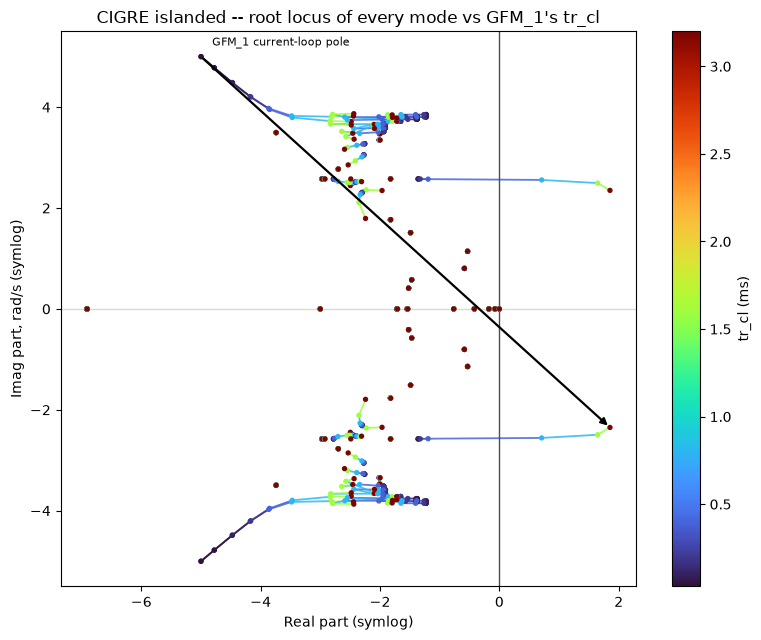

2 mode(s) (besides GFM_1's own current-loop pole) cross from stable to unstable somewhere across this tr_cl sweep


In [19]:
import matplotlib as mpl
from matplotlib.collections import LineCollection

fig, ax = plt.subplots(figsize=(8, 6.5))
cmap = plt.cm.turbo
tnorm = mpl.colors.Normalize(vmin=tr_cl_values.min() * 1e3, vmax=tr_cl_values.max() * 1e3)
tr_cl_ms = tr_cl_values * 1e3


def plot_traces(target_ax, real_part, imag_part, marker_size):
    for row in range(real_part.shape[0]):
        pts = np.array([real_part[row, :], imag_part[row, :]]).T.reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        lc = LineCollection(segs, cmap=cmap, norm=tnorm, linewidth=1.3, alpha=0.85)
        lc.set_array(tr_cl_ms[:-1])
        target_ax.add_collection(lc)
        target_ax.scatter(real_part[row, :], imag_part[row, :], c=tr_cl_ms, cmap=cmap,
                           norm=tnorm, s=marker_size, zorder=3)


plot_traces(ax, symlog(traced.real), symlog(traced.imag), marker_size=8)

# Arrow + label on the swept GFM's own current-loop pole, so its trace (one
# among ~90 here) is easy to pick out -- same trend as the single-pole plot
# above, now visible in the context of every other mode.
cl_re = symlog(np.array([s["cl_eig"].real for s in sweep]))
cl_im = symlog(np.array([s["cl_eig"].imag for s in sweep]))
ax.annotate("", xy=(cl_re[-1], cl_im[-1]), xytext=(cl_re[0], cl_im[0]),
            arrowprops=dict(arrowstyle="-|>", color="k", lw=1.6), zorder=4)
ax.annotate(f"{swept_block_name} current-loop pole", xy=(cl_re[0], cl_im[0]),
            xytext=(8, 8), textcoords="offset points", fontsize=8)

ax.axvline(0, color="0.3", lw=1)
ax.axhline(symlog(0), color="0.85", lw=1)
ax.set_xlabel("Real part (symlog)")
ax.set_ylabel("Imag part, rad/s (symlog)")
ax.set_title(f"CIGRE islanded -- root locus of every mode vs {swept_block_name}'s tr_cl")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=tnorm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("tr_cl (ms)")

# Zoomed inset (linear scale) on the cluster of modes that stay near the
# origin throughout the sweep -- the symlog main axes compress that cluster
# too much to read on its own, the same reason the reference figure this
# was modeled on insets it too.
# near_origin = (np.max(np.abs(traced.real), axis=1) < 50) & (np.max(np.abs(traced.imag), axis=1) < 400)
# if near_origin.any():
#     axins = ax.inset_axes([0.58, 0.05, 0.4, 0.36])
#     plot_traces(axins, traced.real[near_origin, :], traced.imag[near_origin, :], marker_size=10)
#     axins.axvline(0, color="0.3", lw=0.8)
#     axins.set_xlim(-40, 40)
#     axins.set_ylim(-400, 400)
#     axins.tick_params(labelsize=7)
#     axins.set_title(f"near-origin modes ({int(near_origin.sum())})", fontsize=8)

plt.tight_layout()
plt.show()

n_flip = int(np.sum((traced.real[:, 0] < 0) & (traced.real[:, -1] > 0)))
print(f"{n_flip} mode(s) (besides {swept_block_name}'s own current-loop pole) "
      f"cross from stable to unstable somewhere across this tr_cl sweep")

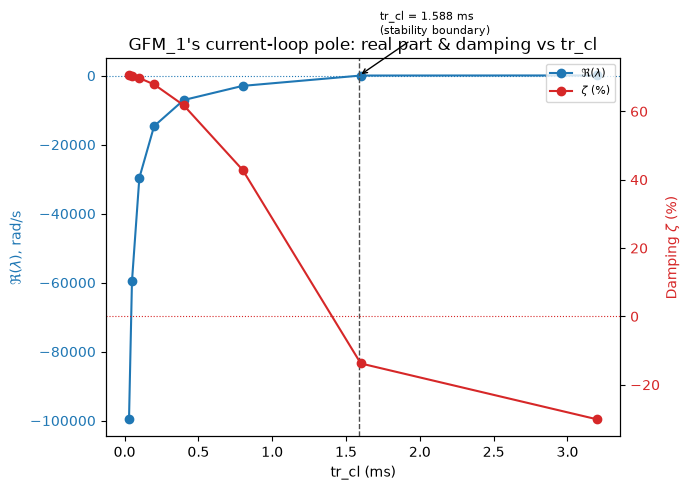

Re(lambda) crosses zero near tr_cl = 1.5884 ms (linear interpolation between the two bracketing sweep samples)


In [20]:
# Real part *and* damping ratio of the swept current-loop pole specifically
# -- the same pair of numbers a controls engineer retunes a loop by, on
# shared x. Damping ratio matches modal.analysis.summary_table()'s own
# convention (-Re(lambda)/|lambda|), not a different definition.
cl_re = np.array([s["cl_eig"].real for s in sweep])
cl_im = np.array([s["cl_eig"].imag for s in sweep])
cl_damp_pct = -cl_re / np.abs(cl_re + 1j * cl_im) * 100

cross_tr_cl_ms = None
for i in range(len(tr_cl_values) - 1):
    r0, r1 = cl_re[i], cl_re[i + 1]
    if (r0 < 0 <= r1) or (r0 >= 0 > r1):
        t0, t1 = tr_cl_ms[i], tr_cl_ms[i + 1]
        cross_tr_cl_ms = t0 + (0 - r0) * (t1 - t0) / (r1 - r0)
        break

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()
l1, = ax1.plot(tr_cl_ms, cl_re, "-o", color="tab:blue", label=r"$\Re(\lambda)$")
l2, = ax2.plot(tr_cl_ms, cl_damp_pct, "-o", color="tab:red", label=r"$\zeta$ (%)")
ax1.axhline(0, color="tab:blue", lw=0.8, ls=":")
ax2.axhline(0, color="tab:red", lw=0.8, ls=":")

if cross_tr_cl_ms is not None:
    ax1.axvline(cross_tr_cl_ms, color="0.3", lw=1, ls="--")
    ax1.annotate(f"tr_cl = {cross_tr_cl_ms:.3f} ms\n(stability boundary)",
                 xy=(cross_tr_cl_ms, 0), xytext=(15, 30), textcoords="offset points", fontsize=8,
                 arrowprops=dict(arrowstyle="->", lw=1))

ax1.set_xlabel("tr_cl (ms)")
ax1.set_ylabel(r"$\Re(\lambda)$, rad/s", color="tab:blue")
ax2.set_ylabel(r"Damping $\zeta$ (%)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title(f"{swept_block_name}'s current-loop pole: real part & damping vs tr_cl")
ax1.legend(handles=[l1, l2], loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

if cross_tr_cl_ms is not None:
    print(f"Re(lambda) crosses zero near tr_cl = {cross_tr_cl_ms:.4f} ms "
          f"(linear interpolation between the two bracketing sweep samples)")
else:
    print("Re(lambda) does not cross zero within the sampled tr_cl range.")

## 10. `modal.toolbox` — sensitivity, mode shape, free response, step response

The rest of `modal_analysis.m`'s toolbox, all pure linear algebra on the
eigendecomposition `analyze()` already computed (or, for step response, a
thin `scipy.signal` wrapper over `system.A/B/C/D`).

In [21]:
from g2elin_core.modal import eigenvalue_sensitivity, mode_shape, free_response, step_response

# Pick the least-damped oscillatory mode (imag != 0) as the interesting one.
osc = [i for i, lam in enumerate(modal.eigenvalues) if abs(lam.imag) > 1e-6]
mode_of_interest = min(osc, key=lambda i: -modal.eigenvalues[i].real)
print("mode of interest:", mode_of_interest, modal.eigenvalues[mode_of_interest])

sens = eigenvalue_sensitivity(modal, system.A, mode_of_interest)
print("\ntop eigenvalue-sensitivity entries:")
for e in sens.top[:5]:
    print(f"  d(lambda)/d(A[{e.row_state}, {e.col_state}]) ~ {e.value:.4g}")

shape = mode_shape(modal, mode_of_interest)
print("\nmode shape (top participating states, phase angle):")
for s, a in zip(shape.states, shape.angles_deg):
    print(f"  {s:20s} {a:7.2f} deg")

mode of interest: 72 (-2.4083525723497052-12.845791697442767j)

top eigenvalue-sensitivity entries:
  d(lambda)/d(A[dw_r_{SM_1}, P_m_{SM_1}]) ~ 38.96
  d(lambda)/d(A[dw_r_{SM_1}, psi_d_{SM_1}]) ~ 6.808
  d(lambda)/d(A[dw_r_{SM_1}, psi_q_{SM_1}]) ~ 5.088
  d(lambda)/d(A[dw_r_{SM_1}, psi_2q_{SM_1}]) ~ 3.906
  d(lambda)/d(A[dw_r_{SM_1}, psi_1d_{SM_1}]) ~ 3.213

mode shape (top participating states, phase angle):
  dw_r_{SM_1}           -49.87 deg
  P_m_{SM_1}           -151.27 deg
  theta_{SM_1}           50.75 deg
  theta_{GFM_1}         153.03 deg
  p_m_{GFM_1}          -127.59 deg


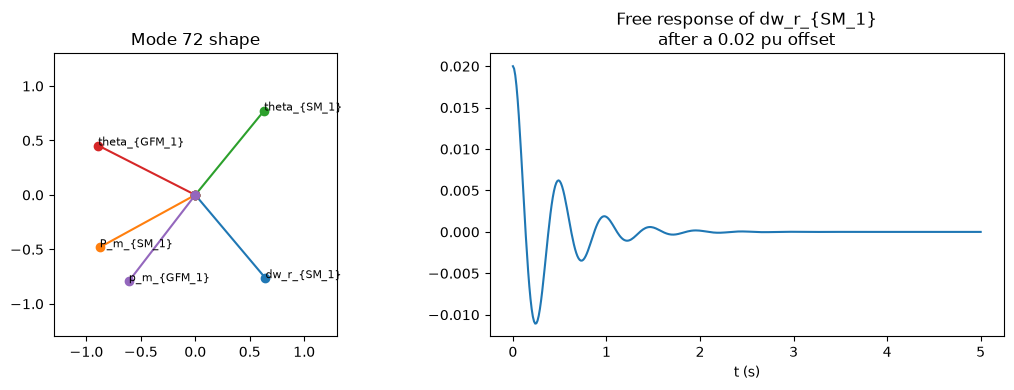

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Polar mode-shape plot.
ax = axes[0]
ax.set_title(f"Mode {mode_of_interest} shape")
for s, a in zip(shape.states, shape.angles_deg):
    rad = math.radians(a)
    ax.plot([0, math.cos(rad)], [0, math.sin(rad)], marker="o")
    ax.annotate(s, (math.cos(rad), math.sin(rad)), fontsize=8)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")

# Closed-form free-motion response of a rotor-speed-deviation state.
ax = axes[1]
dw_idx = next(i for i, n in enumerate(system.state_names) if "dw_r" in n)
t = np.linspace(0, 5, 400)
x_t = free_response(modal, dw_idx, offset=0.02, t=t)
ax.plot(t, x_t[dw_idx, :])
ax.set_title(f"Free response of {system.state_names[dw_idx]}\nafter a 0.02 pu offset")
ax.set_xlabel("t (s)")
plt.tight_layout()
plt.show()

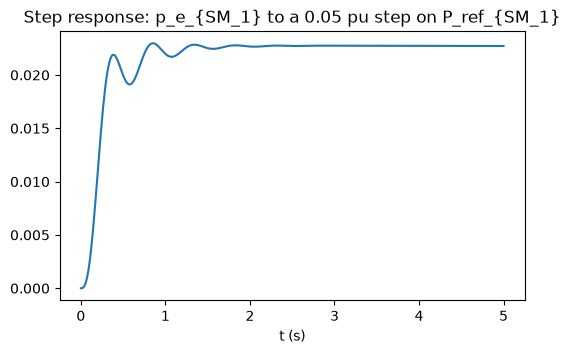

In [23]:
# MIMO step response: pick the slack machine's own P_ref input and its own p_e output.
input_name = next(n for n in system.input_names if "P_ref" in n)
output_name = next(n for n in system.output_names if "p_e" in n)
t = np.linspace(0, 5, 400)
y = step_response(system, input_name, output_name, amplitude=0.05, t=t)

plt.figure(figsize=(6, 3.5))
plt.plot(t, y)
plt.title(f"Step response: {output_name} to a 0.05 pu step on {input_name}")
plt.xlabel("t (s)")
plt.show()

## 11. `timedomain` — nonlinear EMT time-domain simulation

`build_nonlinear_network()` is `pipeline.linearize_network()`'s nonlinear
sibling: same wiring topology, but each block keeps its full nonlinear
`f`/`g`/`h`. `simulate()` integrates the coupled DAE forward in time
(`scipy.integrate.solve_ivp`, `Radau` by default), Newton-solving the
algebraic system at every RHS evaluation. This is what the EMT tab in the
web UI drives.

In [24]:
from g2elin_core.timedomain import build_nonlinear_network, simulate

# Building the model (assembling blocks) is cheap -- it's simulate() below
# that's slow, so this stays unconditional.
model = build_nonlinear_network(net, pf)
print(f"nonlinear model: {len(model.state_names)} states, {len(model.input_names)} inputs, "
      f"{len(model.output_names)} outputs")

nonlinear model: 78 states, 11 inputs, 14 outputs


In [25]:
if RUN_EMT_SECTION:
    # Perturb the same rotor-speed-deviation state by +0.02 pu and integrate.
    x0 = model.initial_state()
    dw_idx = model.state_names.index(system.state_names[dw_idx])
    x0[dw_idx] += 0.02

    result = simulate(model, (0.0, 3.0), x0=x0, t_eval=np.linspace(0, 3, 300))
    print("integrated", len(result.t), "samples; solver success:", result.scipy_result.success)

    plt.figure(figsize=(7, 3.5))
    for name in model.state_names:
        if "dw_r" in name:
            idx = model.state_names.index(name)
            plt.plot(result.t, result.x[idx, :], label=name)
    plt.legend(fontsize=8)
    plt.xlabel("t (s)")
    plt.title("EMT: rotor speed deviations after a 0.02 pu perturbation")
    plt.show()

    # recover_inputs_and_outputs() re-solves the algebraic system at each
    # already-integrated sample to get named input/output trajectories too
    # (not returned by solve_ivp itself, which only tracks states).
    inputs, outputs = model.recover_inputs_and_outputs(result.t, result.x)
    p_e_name = next(n for n in outputs if "p_e" in n)

    plt.figure(figsize=(7, 3.5))
    plt.plot(result.t, outputs[p_e_name])
    plt.xlabel("t (s)")
    plt.title(f"Recovered output: {p_e_name}")
    plt.show()
else:
    print("Skipped -- set RUN_EMT_SECTION = True in the toggles cell near the top and re-run.")

Skipped -- set RUN_EMT_SECTION = True in the toggles cell near the top and re-run.


## 12. `timeseries` — multi-snapshot load flow sweeps

`scale_loads()`/`dispatch_sweep()` build a list of `Snapshot`s (P/Q
overrides), and `run_time_series()` solves each with the ordinary static
power-flow adapter in a plain loop -- no new solver, just repeated calls to
`powerflow.run_power_flow()` on `apply_snapshot()`-modified networks.

In [27]:
from g2elin_core.timeseries import scale_loads, run_time_series

snapshots = scale_loads(net, {"60% load": 0.6, "100% load (base)": 1.0, "115% load": 1.15})
ts = run_time_series(net, snapshots)
print("all converged:", ts.all_converged())
combined = ts.combined_bus_table()
combined.head()

all converged: True


,snapshot,bus,vm_pu,va_degree,p_net_gen_mw,q_net_gen_mvar
0,60% load,1,1.0278,0.5332,-0.0,-0.0
1,60% load,2,1.0257,7.4608,-0.0,-0.0
2,60% load,3,1.0613,7.7910,-0.0,-0.0
3,60% load,4,1.0135,0.6110,-75.0,-30.0
4,60% load,5,1.0366,6.2670,-60.0,-21.0


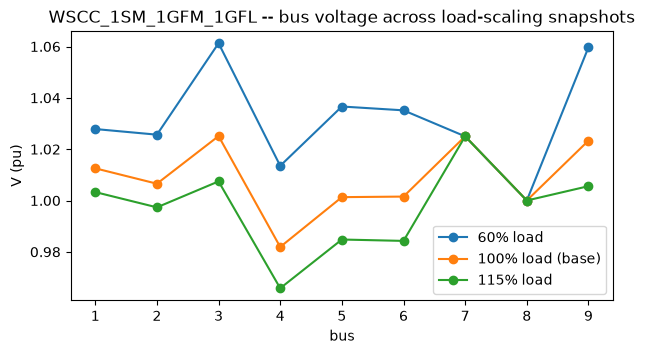

In [28]:
pivot = combined.pivot(index="bus", columns="snapshot", values="vm_pu")
pivot = pivot[["60% load", "100% load (base)", "115% load"]]

plt.figure(figsize=(7, 3.5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)
plt.xlabel("bus")
plt.ylabel("V (pu)")
plt.title(f"{net.name} -- bus voltage across load-scaling snapshots")
plt.legend()
plt.show()

## Where to go from here

- Swap `net = wscc9_3sm()` in section 1 for `cigre_islanded_1sm_2gfm_1gfl()`,
  `sm_smib()`, `gfm_smib()`, or `gfl_smib()` and re-run -- every section
  after that is preset-agnostic.
- `g2elin_api` wraps the same functions used here behind HTTP
  (`src/g2elin_api/main.py`), and `web/index.html` is the browser client
  for that API -- run `uvicorn g2elin_api.main:app --app-dir src` from
  `python/` to explore the same analyses interactively in a browser.
- The Sphinx docs (`docs/sphinx`, built via `python tools/build_docs.py`,
  served at `/manual` by the running API) go deeper on the *why* behind
  each module's design than this notebook's inline comments do.